# Lesson 3: One-Sample Tests for Means and Proportions

**Course:** hypothesis_testing_and_statistical_inference  
**Prerequisites:** Basic Python and descriptive statistics

This lesson follows a repeatable workflow: define the question, encode the design,
check assumptions, estimate the effect, quantify uncertainty, test the claim, and
communicate both statistical and practical meaning.


## Learning objectives

1. Run and report a one-sample t-test with a confidence interval and standardized effect
2. Choose between an exact binomial test and a large-sample proportion test
3. Check assumptions and identify when a one-sample test cannot support a causal claim
4. Interpret one-sided tests correctly


## Setup

Run this cell first. Every example uses a fixed random seed so results are reproducible.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Work whether the kernel starts in the course root or a level folder.
working_dir = Path.cwd()
COURSE_ROOT = working_dir if (working_dir / "data").exists() else working_dir.parent
DATA_DIR = COURSE_ROOT / "data"

rng = np.random.default_rng(20260920)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.precision", 4)


## 3.1 One-sample mean

For independent quantitative observations, the one-sample t statistic is
$$t=\frac{\bar{x}-\mu_0}{s/\sqrt{n}},\qquad df=n-1.$$
Independence comes from the sampling process. For small samples, inspect the distribution for severe
skew or influential outliers; for large samples, the mean is often robust to modest non-normality.


In [2]:
anes = pd.read_csv(DATA_DIR / "anes96_clean.csv")
respondent_age = anes["age_years"].dropna().to_numpy()
target = 45
test = stats.ttest_1samp(respondent_age, popmean=target)
n = len(respondent_age)
mean = respondent_age.mean()
sd = respondent_age.std(ddof=1)
ci = stats.t.interval(.95, n-1, loc=mean, scale=sd/np.sqrt(n))
d = (mean-target)/sd
pd.Series({"n": n, "mean age": mean, "SD": sd, "t": test.statistic,
           "df": n-1, "p": test.pvalue, "Cohen d": d,
           "CI low": ci[0], "CI high": ci[1]})


n           944.0000
mean age     47.0434
SD           16.4231
t             3.8229
df          943.0000
p             0.0001
Cohen d       0.1244
CI low       45.9944
CI high      48.0924
dtype: float64

/Users/soroush/Library/Python/3.9/lib/python/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/Users/soroush/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


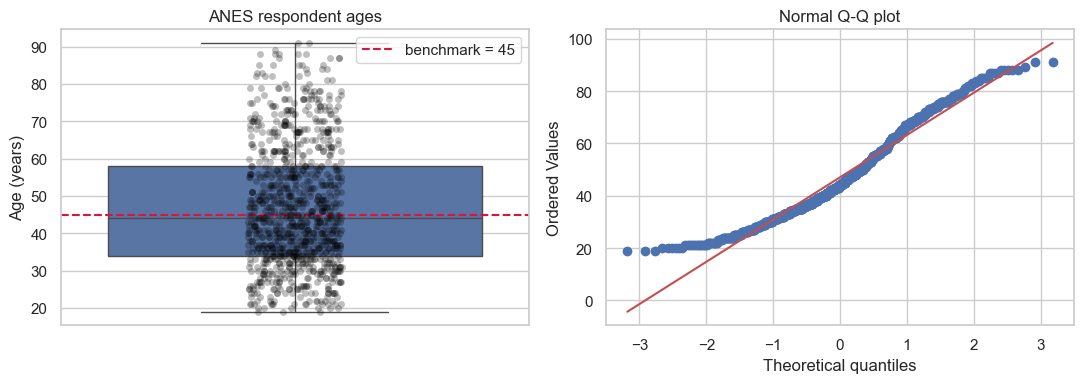

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=respondent_age, ax=axes[0])
sns.stripplot(y=respondent_age, color="black", alpha=.25, ax=axes[0])
axes[0].axhline(target, color="crimson", linestyle="--", label="benchmark = 45")
axes[0].set(title="ANES respondent ages", ylabel="Age (years)")
axes[0].legend()
stats.probplot(respondent_age, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q plot")
plt.tight_layout(); plt.show()


## 3.2 One-sample proportion

Use the exact binomial test when the sample is small or the null proportion is near 0 or 1. A normal
approximation is reasonable when $np_0$ and $n(1-p_0)$ are both sufficiently large. For intervals,
Wilson or exact intervals behave better than the simple Wald interval.


In [4]:
spector = pd.read_csv(DATA_DIR / "spector_program.csv")
successes = int(spector["grade_improved"].sum())
trials = len(spector)
p0 = .50
exact = stats.binomtest(successes, trials, p=p0, alternative="two-sided")
ci = exact.proportion_ci(confidence_level=.95, method="wilson")
p_hat = successes/trials
cohen_h = 2*(np.arcsin(np.sqrt(p_hat))-np.arcsin(np.sqrt(p0)))
pd.Series({"students whose grade improved": successes, "n": trials, "p-hat": p_hat,
           "exact p": exact.pvalue, "Cohen h": cohen_h,
           "Wilson low": ci.low, "Wilson high": ci.high})


students whose grade improved    11.0000
n                                32.0000
p-hat                             0.3438
exact p                           0.1102
Cohen h                          -0.3178
Wilson low                        0.2041
Wilson high                       0.5169
dtype: float64

## Worked example and interpretation

### Mean benchmark

The ANES example takes 944 respondent ages and tests a mean of 45 years. It calculates the sample mean (47.04), standard deviation (16.42), standard error, t statistic (3.823 on 943 degrees of freedom), and a 95% interval for the mean (45.99 to 48.09). Cohen's d is 0.124, so the statistically detectable difference from 45 is small relative to age variation. The box-and-point plot shows individual spread against the benchmark; the Q–Q plot is a diagnostic for the shape of the ages, not a mechanical test-selection switch. Independence still depends on how respondents were sampled.

### Proportion benchmark

The Spector example counts 11 grade improvements among 32 students, an observed proportion of 0.344. It compares this with a **teaching** benchmark of 0.50 using a two-sided exact binomial test because the sample is small. The exact p-value is 0.110, while the Wilson 95% interval is 0.204 to 0.517 and Cohen's h is −0.318. These results leave both lower rates and the 0.50 reference compatible with the data; failing to reject does not establish equality. Neither benchmark comparison explains *why* the observed value differs.

## Practice and solution

**Practice.** A manufacturer claims fewer than 2% of parts are defective. In a random sample of 100,
4 are defective. Write the hypotheses and identify an appropriate test.

<details><summary>Solution</summary>

For a claim that the defect rate is below 2%, use $H_0:p\ge .02$ versus $H_1:p<.02$, operationally
tested at the boundary $p=.02$ with a one-sided exact binomial test. Because only two defects are
expected under the boundary null, the exact test is preferable to a normal approximation. Observing
four defects points opposite to the stated alternative, so the data cannot support "below 2%."
</details>

## Key takeaways

- Match the parameter and direction to the claim before seeing results.
- Exact methods are especially useful for small or extreme proportions.
- A test of a benchmark does not establish why a sample differs from it.


## Reproducibility checklist

- State the population, outcome, groups, and sampling unit.
- State $H_0$, $H_1$, alpha, and whether the test is one- or two-sided before looking at results.
- Verify independence from the design; use plots and diagnostics for distributional assumptions.
- Report the estimate, confidence interval, effect size, test statistic, degrees of freedom, and exact p-value.
- Separate statistical evidence from practical importance and acknowledge design limitations.
